# SECTION 1: CONFIGURATION & DATA LOADING

In [1]:
# ==============================================================================
# 1.1 Configuration Variables
# ==============================================================================

## INPUT DATA - Change this to switch datasets
params_file <- '../../data/model_in/parameters_for_model_curated_2569_no_na_31-01-25.tsv'

# Alternative files (uncomment to use):
#params_file <- './test_with_change_of_W.tsv'
# params_file <- '../../data/model_in/parameters_alternative.tsv'

## MODEL PARAMETERS
split_seed <- 4321  # Random seed for train/test split
train_ratio <- 0.7  # 70% training, 30% testing
include_evaders <- FALSE  # TRUE to include evader phenotype in training
variance_threshold <- 0  # Remove features with variance <= this value

## NESTED CV PARAMETERS
outer_folds <- 10
inner_folds <- 10

## ROBUSTNESS TESTING
RUN_ROBUSTNESS_TESTING <- FALSE  # it's just long

## ADDITIONAL FILES (for cluster/sequence analysis)
clust_file <- '../../data/model_in/clust.faa.clstr'
exp_fla_file <- '../../data/model_in/experimental_flagellins.fasta'

## 1.2 Initialize Libraries

In [2]:
suppressMessages({
library(ggplot2)
library(splitTools)
library(tibble)
library(randomForest)
library(caret)
library(nestedcv)
library(ggforce)
library(dplyr)
library(tidyr)
library(pwalign)
library(Biostrings)
library(gridExtra)
library(ggpubr)
library(pROC)
library(patchwork) 
})

suppressWarnings(library(LeyLabRMisc))

## 1.3 Load Functions

In [3]:
source('./model_notebook_functions.R')

In [4]:
df.dims(3)

## 1.4 Load Data

In [5]:
df <- read.table(params_file, sep = "\t", header = TRUE, row.names = 1)

# Convert European decimal format to numeric (safety check)
if ("avg.activity" %in% colnames(df)) {
    df <- df %>% mutate(
        avg.activity = gsub(',', '.', avg.activity),
        avg.activity = as.numeric(avg.activity),
        avg.binding = gsub(',', '.', avg.binding),
        avg.binding = as.numeric(avg.binding)
    )
}

# Ensure Exp.phenotype is factor with standard levels
if ("Exp.phenotype" %in% colnames(df)) {
    df$Exp.phenotype <- factor(df$Exp.phenotype,
                               levels = c("active", "silent", "evader"))
}

# Identify feature columns (those starting with f_)
feature_cols <- grep('^f_', colnames(df), value = TRUE)
cat("Loaded dataset:", nrow(df), "samples,", length(feature_cols), "features\n")

# critical columns exist
required_cols <- c('Exp.phenotype', 'Cluster_CDHit')
missing_cols <- setdiff(required_cols, colnames(df))
if (length(missing_cols) > 0) {
    warning("Missing expected columns: ", paste(missing_cols, collapse = ", "))
}

Loaded dataset: 2462 samples, 53 features


## 1.5 Prepare Dataset for Modeling

In [6]:
# filter to experimental samples (has Exp.phenotype)
df_exp <- df %>% filter(!is.na(Exp.phenotype))
cat("Experimental samples:", nrow(df_exp), "\n")

# phenotype distribution
cat("\nPhenotype distribution:\n")
print(table(df_exp$Exp.phenotype))

# exclude evaders if configured (they are underrepresented)
if (!include_evaders) {
    df_exp <- df_exp %>% filter(Exp.phenotype != 'evader')
    df_exp$Exp.phenotype <- droplevels(df_exp$Exp.phenotype)
    cat("\nAfter excluding evaders:", nrow(df_exp), "samples\n")
    print(table(df_exp$Exp.phenotype))
}

# remove experimental measurements (these are target-related, not predictive features)
df_exp_model <- df_exp %>% select(-c(avg.binding, avg.activity))

cat("\nReady for modeling:", nrow(df_exp_model), "samples\n")

Experimental samples: 119 

Phenotype distribution:

active silent evader 
    40     52     27 

After excluding evaders: 92 samples

active silent 
    40     52 

Ready for modeling: 92 samples


# SECTION 2: TRAIN/TEST SPLIT & MODEL TRAINING

## 2.1 Split train and test

In [7]:
colnames(df_exp_model)

[1] "Cluster_CDHit"           "sequence"               
 [3] "Exp.phenotype"           "f_R.K478_r_k"           
 [5] "f_E78_charge"            "f_L88_charge"           
 [7] "f_Q89_charge"            "f_R90_charge"           
 [9] "f_L94_charge"            "f_A95_charge"           
[11] "f_Q97_charge"            "f_N100_charge"          
[13] "f_S101_charge"           "f_N103_charge"          
[15] "f_S104_charge"           "f_A113_charge"          
[17] "f_T116_charge"           "f_Q117_charge"          
[19] "f_I422_charge"           "f_V439_charge"          
[21] "f_Q440_charge"           "f_S445_charge"          
[23] "f_A446_charge"           "f_I447_charge"          
[25] "f_N449_charge"           "f_R.K478_charge"        
[27] "f_E78_hydrophobicity"    "f_L88_hydrophobicity"   
[29] "f_Q89_hydrophobicity"    "f_R90_hydrophobicity"   
[31] "f_L94_hydrophobicity"    "f_A95_hydrophobicity"   
[33] "f_Q97_hydrophobicity"    "f_N100_hydrophobicity"  
[35] "f_S101_hydrophobicity"   "f_N103_hydrophobicity"  
[37] "f_S104_hydrophobicity"   "f_A113_hydrophobicity"  
[39] "f_T116_hydrophobicity"   "f_Q117_hydrophobicity"  
[41] "f_I422_hydrophobicity"   "f_V439_hydrophobicity"  
[43] "f_Q440_hydrophobicity"   "f_S445_hydrophobicity"  
[45] "f_A446_hydrophobicity"   "f_I447_hydrophobicity"  
[47] "f_N449_hydrophobicity"   "f_R.K478_hydrophobicity"
[49] "f_pident_FlaB"           "f_length_FlaB"          
[51] "f_mismatch_FlaB"         "f_pident_FliC"          
[53] "f_length_FliC"           "f_mismatch_FliC"        
[55] "f_alntmscore_foldseek"   "f_rmsd_foldseek"

In [8]:
result <- split_train_test(df_exp_model, split_seed)
train <- result[[1]]
test <- result[[2]]

#remove metadata columns before modeling
train <- train %>% select(-c(sequence, Cluster_CDHit))
test <- test %>% select(-c(Cluster_CDHit, sequence))


cat("Training set size:", nrow(train), "sequences\n")
cat("Testing set size:", nrow(test), "sequences\n")

cat("\nPhenotype distribution in training set:\n")
print(table(train$Exp.phenotype))

cat("\nPhenotype distribution in testing set:\n")
print(table(test$Exp.phenotype))

Training set size: 64 sequences
Testing set size: 28 sequences

Phenotype distribution in training set:

active silent 
    28     36 

Phenotype distribution in testing set:

active silent 
    12     16 


In [9]:
train

,Exp.phenotype,f_R.K478_r_k,f_E78_charge,f_L88_charge,f_Q89_charge,f_R90_charge,f_L94_charge,f_A95_charge,f_Q97_charge,f_N100_charge,⋯,f_N449_hydrophobicity,f_R.K478_hydrophobicity,f_pident_FlaB,f_length_FlaB,f_mismatch_FlaB,f_pident_FliC,f_length_FliC,f_mismatch_FliC,f_alntmscore_foldseek,f_rmsd_foldseek
,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>
Q549S3_StFliC,active,1,-1,0,0,1,0,0,0,0,⋯,1,1,46.8,47,25,98.3,179,3,0.9271,4.215
WP_065534017_1,silent,1,-1,0,0,1,0,0,0,0,⋯,1,1,43.1,116,66,48.0,123,63,0.9693,1.108
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
RHP21408_1,silent,0,-1,0,0,1,0,0,0,0,⋯,0,1,46.7,122,59,45.4,130,71,0.9687,1.033


## 2.2 Feature Selection on Training Set

In [10]:
## 2.2 Feature Selection on Training Set

# Apply low variance filtering to training set ONLY
# This is different from the global variance assessment in merging-params

train_cleaned <- filter_low_variance(train, variance_threshold)
test_cleaned <- test %>% select(all_of(colnames(train_cleaned)))

cat("\nAfter variance filtering:\n")
cat("Training set:", nrow(train_cleaned), "samples,",
    length(grep('^f_', colnames(train_cleaned), value = TRUE)), "features\n")

* N of features initially: 54 
* N of features with variance <= 0 : 15 
* Namely: f_E78_charge f_L88_charge f_Q89_charge f_R90_charge f_L94_charge f_A95_charge f_I422_charge f_V439_charge f_A446_charge f_N449_charge f_E78_hydrophobicity f_L88_hydrophobicity f_R90_hydrophobicity f_L94_hydrophobicity f_Q97_hydrophobicity 
* N of features after filtration: 39
After variance filtering:
Training set: 64 samples, 38 features


In [11]:
train_cleaned %>% group_by(Exp.phenotype) %>% count()

Exp.phenotype,n
<fct>,<int>
active,28
silent,36


In [12]:
train_cleaned

,Exp.phenotype,f_R.K478_r_k,f_Q97_charge,f_N100_charge,f_S101_charge,f_N103_charge,f_S104_charge,f_A113_charge,f_T116_charge,f_Q117_charge,⋯,f_N449_hydrophobicity,f_R.K478_hydrophobicity,f_pident_FlaB,f_length_FlaB,f_mismatch_FlaB,f_pident_FliC,f_length_FliC,f_mismatch_FliC,f_alntmscore_foldseek,f_rmsd_foldseek
,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>
Q549S3_StFliC,active,1,0,0,0,0,0,0,0,0,⋯,1,1,46.8,47,25,98.3,179,3,0.9271,4.215
WP_065534017_1,silent,1,0,0,0,0,0,1,-1,0,⋯,1,1,43.1,116,66,48.0,123,63,0.9693,1.108
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
RHP21408_1,silent,0,0,0,-1,0,0,1,-1,0,⋯,0,1,46.7,122,59,45.4,130,71,0.9687,1.033


## 2.3 Train Model with Nested Cross-Validation

In [13]:
res1 = train_model_nestedcv(train_cleaned)

Fitting final model using CV on whole data

Duration: 24.45981 secs



In [14]:
summary(res1)

Nested cross-validation with caret
Method:  method 
No filter
Outer loop:  10-fold cv
Inner loop:  10-fold cv
64 observations, 38 predictors
active silent 
    28     36 

         mtry  n.filter
Fold 1      2        38
Fold 2      2        38
Fold 3      2        38
Fold 4      2        38
Fold 5      2        38
Fold 6      2        38
Fold 7      2        38
Fold 8      2        38
Fold 9     38        38
Fold 10     2        38

Final parameters:
  mtry
     2

Result:
         Reference
Predicted active silent
   active     21      5
   silent      7     31

              AUC            Accuracy   Balanced accuracy   
           0.8304              0.8125              0.8056   


In [15]:
summary(res1)

Nested cross-validation with caret
Method:  method 
No filter
Outer loop:  10-fold cv
Inner loop:  10-fold cv
64 observations, 38 predictors
active silent 
    28     36 

         mtry  n.filter
Fold 1      2        38
Fold 2      2        38
Fold 3      2        38
Fold 4      2        38
Fold 5      2        38
Fold 6      2        38
Fold 7      2        38
Fold 8      2        38
Fold 9     38        38
Fold 10     2        38

Final parameters:
  mtry
     2

Result:
         Reference
Predicted active silent
   active     21      5
   silent      7     31

              AUC            Accuracy   Balanced accuracy   
           0.8304              0.8125              0.8056   


## 2.4 Test Model on Hold-Out Test Set

In [16]:
# predict on test set
test_cleaned$pred1 <- as.vector(predict(res1, newdata = test_cleaned))

# confusion matrix
levels_to_use <- union(levels(test_cleaned$Exp.phenotype), unique(test_cleaned$pred1))
test_cleaned$pred1 <- factor(test_cleaned$pred1, levels = levels_to_use)
test_cleaned$Exp.phenotype <- factor(test_cleaned$Exp.phenotype, levels = levels_to_use)

conf_mat <- confusionMatrix(test_cleaned$pred1, test_cleaned$Exp.phenotype)
print(conf_mat)

Confusion Matrix and Statistics

          Reference
Prediction active silent
    active     10      2
    silent      2     14
                                          
               Accuracy : 0.8571          
                 95% CI : (0.6733, 0.9597)
    No Information Rate : 0.5714          
    P-Value [Acc > NIR] : 0.001268        
                                          
                  Kappa : 0.7083          
                                          
 Mcnemar's Test P-Value : 1.000000        
                                          
            Sensitivity : 0.8333          
            Specificity : 0.8750          
         Pos Pred Value : 0.8333          
         Neg Pred Value : 0.8750          
             Prevalence : 0.4286          
         Detection Rate : 0.3571          
   Detection Prevalence : 0.4286          
      Balanced Accuracy : 0.8542          
                                          
       'Positive' Class : active          
            

In [17]:
## Table 1: Summary of model performance metrics
cat("Table 1: Classification model performance on hold-out test set\n")
cat("=========================================================\n")
cat(sprintf("  Accuracy:           %.3f\n", conf_mat$overall['Accuracy']))
cat(sprintf("  Sensitivity:        %.3f\n", conf_mat$byClass['Sensitivity']))
cat(sprintf("  Specificity:        %.3f\n", conf_mat$byClass['Specificity']))
cat(sprintf("  Pos Pred Value:     %.3f\n", conf_mat$byClass['Pos Pred Value']))
cat(sprintf("  Neg Pred Value:     %.3f\n", conf_mat$byClass['Neg Pred Value']))
cat(sprintf("  Balanced Accuracy:  %.3f\n", conf_mat$byClass['Balanced Accuracy']))
cat(sprintf("  F1:                 %.3f\n", conf_mat$byClass['F1']))
cat("=========================================================\n")

Table 1: Classification model performance on hold-out test set


  Accuracy:           0.857
  Sensitivity:        0.833
  Specificity:        0.875
  Pos Pred Value:     0.833
  Neg Pred Value:     0.875
  Balanced Accuracy:  0.854
  F1:                 0.833


# SECTION 3: VISUALIZATION & ANALYSIS

## 3.1 Confusion Matrix Plot

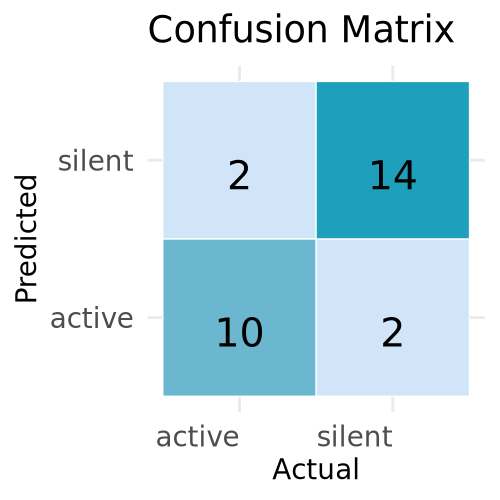

In [18]:
p.dims(2.5, 2.5)
confusion <- as.table(conf_mat$table)
p_cm = ggplot(data = as.data.frame(confusion), aes(x = Reference, y = Prediction, fill = Freq)) +
    geom_tile(color = "white") +
    geom_text(aes(label = sprintf("%1.0f", Freq)), vjust = 1, size = 5) +
    scale_fill_gradient(low = "#d0e6f8", high = "#1ea0bd") +
    theme_minimal() +
    theme(axis.text.x = element_text(hjust = 1, size = 10),
            axis.text=element_text(size=10),
            axis.title=element_text(size=10),
            #plot.title=element_text(size=5),
            #legend.text=element_text(size=5),
            legend.title=element_text(size=5)) +
    theme(legend.position = "none") + # delete legend title ) +
    labs(title = "Confusion Matrix", x = "Actual", y = "Predicted")
print(p_cm)


## 3.2 ROC Curve (Figure 2b)

In [19]:
cat('The probability with which the model predicts a class for each observation in the test set.')
predict(res1, newdata = test, type = "prob")

The probability with which the model predicts a class for each observation in the test set.

,active,silent
,<dbl>,<dbl>
P0C6C4_VcFlaB,0.710,0.290
WP_118747250_1,0.624,0.376
⋮,⋮,⋮
Q5Y831_LmFlaA,0.526,0.474


In [20]:
# probability matrix
probs <- predict(res1, newdata = test, type = "prob")

test$pred1_prob <- probs[, "silent"]  # positive class

Setting levels: control = active, case = silent



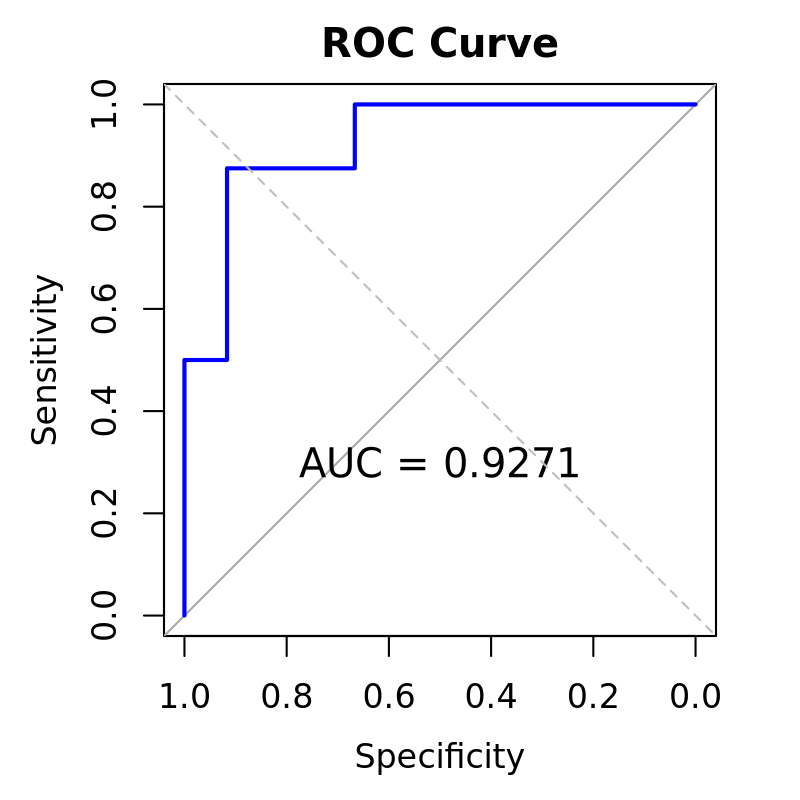

In [21]:
p.dims(4, 4)

roc_obj <- roc(test$Exp.phenotype, test$pred1_prob, direction = "<")

plot(roc_obj, 
     main = "ROC Curve",
     col = "blue", 
     lwd = 2)


text(0.5, 0.3, 
     paste("AUC =", round(auc(roc_obj), 4)), 
     cex = 1.2)

# random classifier
abline(a = 0, b = 1, lty = 2, col = "gray")

## 3.3 Feature Importance (SFigure 2)

In [22]:
importance = cv_varImp(res1)
importance

,,,,,,,,,,,Final
f_R.K478_r_k,28.46044,35.28089,24.66546,36.41104,42.38740,33.28818,29.576436,31.92093,7.310718,22.16416,37.35488
f_Q97_charge,11.98777,12.99649,13.60027,11.99676,17.29831,9.25088,9.076284,11.48324,3.659732,12.08936,12.86606
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
f_rmsd_foldseek,64.34543,62.79957,64.19113,55.98667,65.9405,74.69058,56.40815,70.88848,21.19728,64.53988,70.80752


In [23]:
importance %>% as.data.frame() %>% arrange(Final)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Final
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
f_I422_hydrophobicity,0.9441748,0.6912306,0.000000,0.00000,0.00000,1.030689,0.000000,0.000000,0.00000000,0.00000,0.000000
f_N100_charge,0.0000000,0.0000000,1.318948,1.41416,4.01791,1.635032,1.883976,1.863567,0.05722848,3.34502,0.284768
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
f_pident_FlaB,93.95736,100,84.65589,97.73909,89.35351,90.19252,98.69275,96.1581,46.25743,85.07485,100


In [24]:
df_var <- var_stability(res1) 
df_var

,mean,sd,sem,frequency,sign,direction,final
,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<fct>,<fct>
f_mismatch_FlaB,93.87993,7.324277,2.208352,11,-1,Up in active,yes
f_pident_FliC,91.68232,7.523651,2.268466,11,-1,Up in active,yes
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
f_I422_hydrophobicity,0.2423722,0.4225398,0.1274005,3,1,Up in silent,yes


Warning message:
“`geom_errobarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggplot2 package.
  Please report the issue at <https://github.com/tidyverse/ggplot2/issues>.”
`height` was translated to `width`.


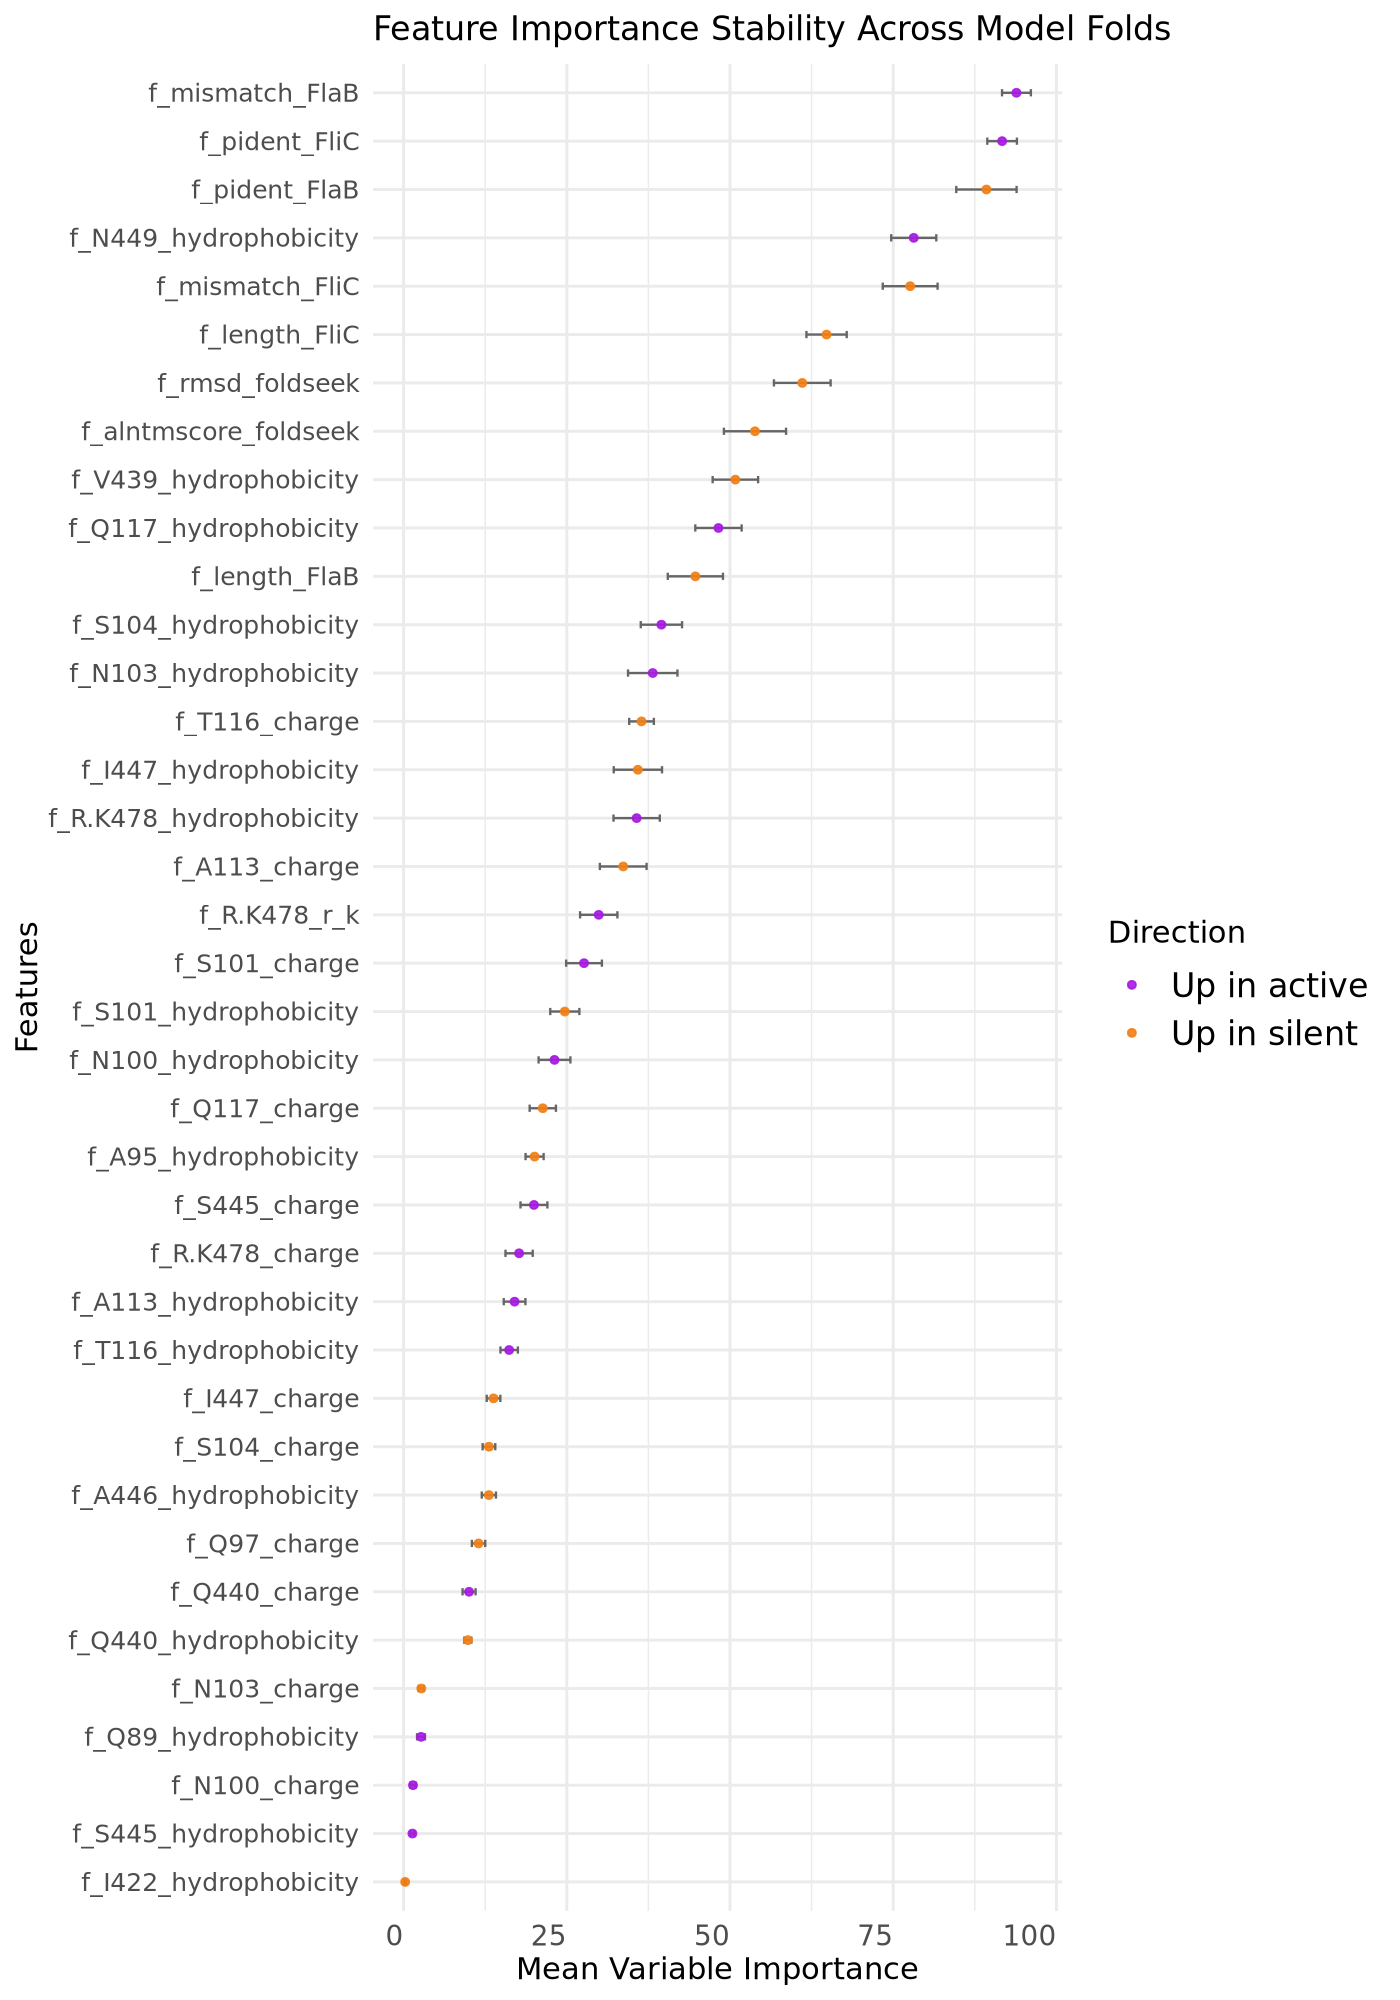

In [25]:
p.dims(7, 10)

# Define customizable parameters in advance for convenience
point_size <- 1.0          
errorbar_size <- 0.4       
errorbar_height <- 0.15    
point_alpha <- 0.9         

ggplot(df_var, aes(x = mean, y = reorder(rownames(df_var), mean))) +
  geom_errorbarh(aes(xmin = mean - sem, xmax = mean + sem), 
                 height = errorbar_height,
                 size = errorbar_size,
                 color = "gray40") + 
  geom_point(aes(color = direction), 
             size = point_size,
             alpha = point_alpha) +
  scale_color_manual(values = c("Up in active" = "#a71ae3", 
                               "Up in silent" = "#f18015")) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(hjust = 1, vjust = 1, size = 10),
    axis.text.y = element_text(size = 9),     # Slightly smaller for feature names
    axis.title = element_text(size = 11), 
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 11),
    plot.title = element_text(size = 12),
    plot.caption = element_text(size = 9, color = "gray50")
  ) +
  labs(
    title = "Feature Importance Stability Across Model Folds", 
    x = "Mean Variable Importance",
    y = "Features",
    color = "Direction"
  )

## 3.4 Model Robustness Testing SFigure 3
Set RUN_ROBUSTNESS_TESTING = TRUE to run computationally expensive robustness testing with label shuffling

In [26]:
if (RUN_ROBUSTNESS_TESTING) {
    cat("Running robustness testing with shuffled labels...\n")
    
    # Shuffle the labels in the train dataset
    train_shuffle <- train
    train_shuffle[["Exp.phenotype"]] <- sample(train_shuffle[["Exp.phenotype"]])
    
    res2 = train_model_nestedcv(train_shuffle)
    summary(res2)
} else {
    cat("Skipping robustness testing (set RUN_ROBUSTNESS_TESTING = TRUE to run)\n")
}

Skipping robustness testing (set RUN_ROBUSTNESS_TESTING = TRUE to run)


In [27]:
res2 <- readRDS("../../../notebooks/annotation/functional/res2_v3_100.rds") 

In [28]:
results <- res2 %>% #rename(Method = 'Label') %>%
    mutate(Method = case_when(
        Method == 'random_cluster_shuffle' ~ 'shuffled_labels',
        Method == 'random_split' ~ 'correct_labels'
    ))


In [29]:
# Prepare long-format metrics and comparisons for robustness plot
metrics_long <- results %>%
    select(Method, Iteration, TestAccuracy, Sensitivity, Specificity, 
           PPV, NPV, F1, BalancedAccuracy) %>%
    pivot_longer(cols = c(TestAccuracy, Sensitivity, Specificity, 
                         PPV, NPV, F1, BalancedAccuracy),
                names_to = "Metric", values_to = "Value")

# Calculate y-positions for significance labels
y_positions <- metrics_long %>%
    group_by(Metric) %>%
    summarize(y.position = max(Value, na.rm = TRUE) * 1.15)

metrics_long <- metrics_long %>%
    left_join(y_positions, by = "Metric")

comparisons <- list(c("correct_labels", "shuffled_labels"))

### SFigure 3 A: Confusion Matrices (100 iterations)

In [30]:
# Confusion matrices for correct vs shuffled labels (mean +/- sd over 100 iterations)
p.dims(5.5, 2.5)

# Calculate mean and sd for each confusion matrix cell by method
cm_summary <- results %>%
    group_by(Method) %>%
    summarize(
        TP_mean = mean(TP, na.rm = TRUE), TP_sd = sd(TP, na.rm = TRUE),
        FP_mean = mean(FP, na.rm = TRUE), FP_sd = sd(FP, na.rm = TRUE),
        TN_mean = mean(TN, na.rm = TRUE), TN_sd = sd(TN, na.rm = TRUE),
        FN_mean = mean(FN, na.rm = TRUE), FN_sd = sd(FN, na.rm = TRUE),
        .groups = 'drop'
    )

# Get class labels from the data
pos_label <- na.omit(unique(results$positive_class))[1]
neg_label <- na.omit(unique(results$negative_class))[1]


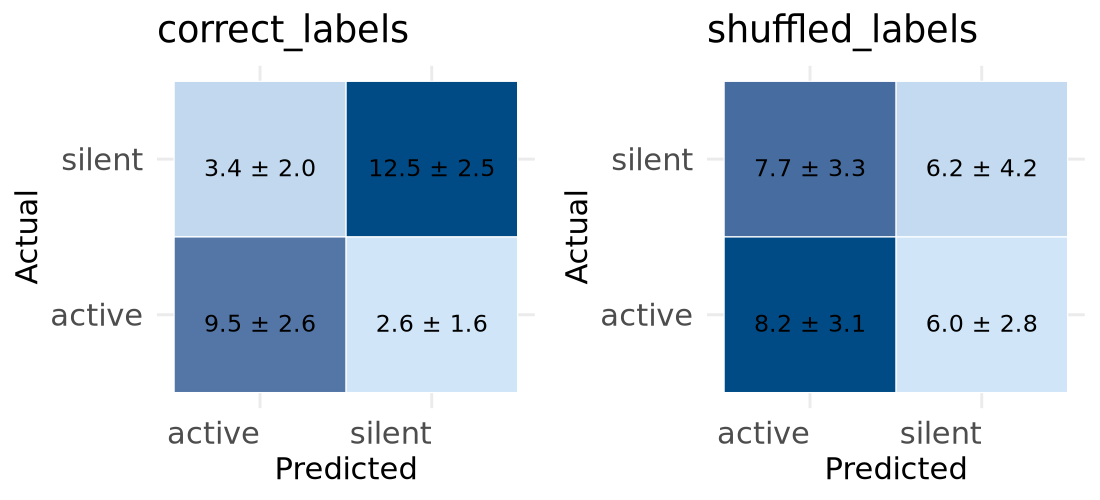

In [31]:

# Create confusion matrix plots per method
cm_plots <- lapply(unique(results$Method), function(m) {
    md <- cm_summary %>% filter(Method == m)

    plot_data <- data.frame(
        Position = c('TP', 'FP', 'FN', 'TN'),
        Mean = c(md$TP_mean, md$FP_mean, md$FN_mean, md$TN_mean),
        SD   = c(md$TP_sd,   md$FP_sd,   md$FN_sd,   md$TN_sd)
    )
    plot_data$Label <- sprintf('%.1f ± %.1f', plot_data$Mean, plot_data$SD)

    plot_data$row <- c(2, 1, 2, 1)  # TP, FP, FN, TN
    plot_data$col <- c(2, 2, 1, 1)

    ggplot(plot_data, aes(x = factor(col), y = factor(row))) +
        geom_tile(aes(fill = Mean), color = 'white') +
        geom_text(aes(label = Label), vjust = 1, size = rel(3)) +
        scale_fill_gradient(low = '#d0e6f8', high = '#004b86ff') +
        theme_minimal() +
        theme(
            axis.text.x = element_text(hjust = 1, size = rel(1)),
            axis.text   = element_text(size = rel(1)),
            axis.title  = element_text(size = rel(1)),
            legend.title = element_text(size = rel(1)),
            legend.position = 'none'
        ) +
        scale_x_discrete(labels = c(neg_label, pos_label)) +
        scale_y_discrete(labels = c(neg_label, pos_label)) +
        labs(title = m, x = 'Predicted', y = 'Actual')
})

do.call(gridExtra::grid.arrange, c(cm_plots, ncol = 2))

### Supp. Fig 3 B

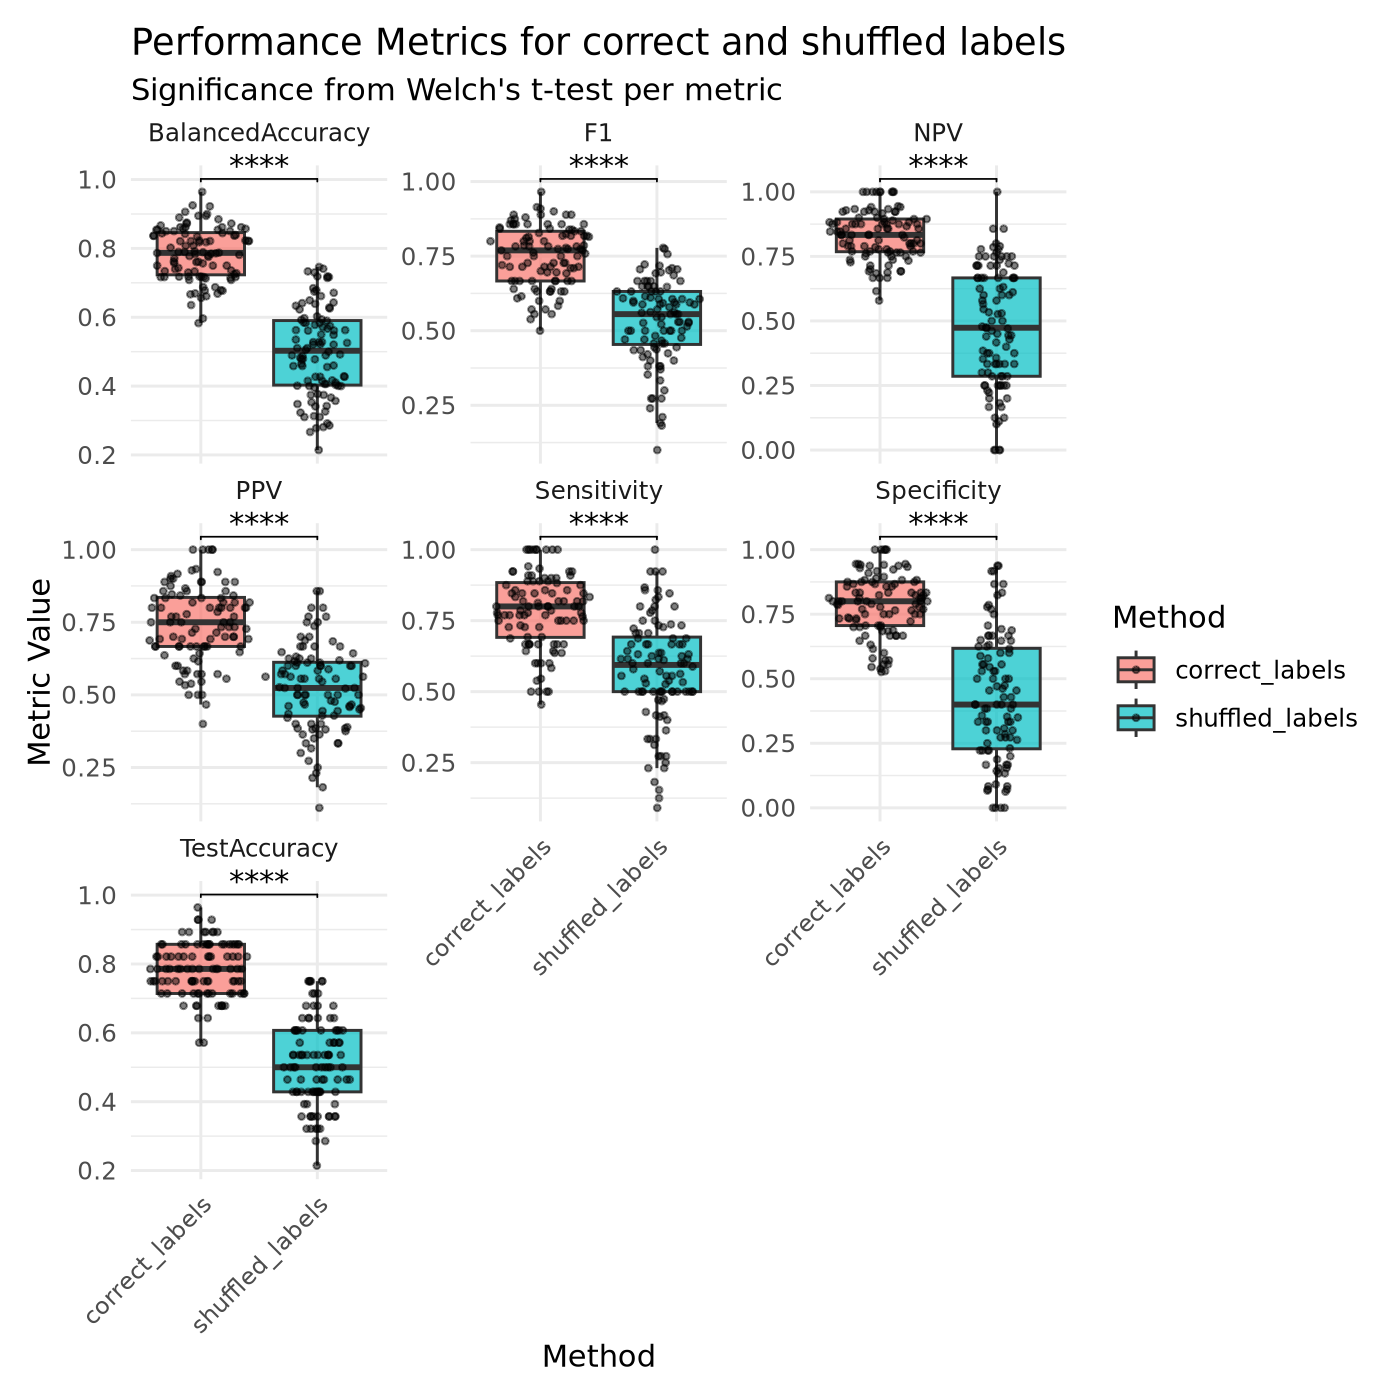

In [32]:
p.dims(7, 7)
plot_robustness_comparison_metrics(metrics_long, comparisons)

## 3.5 Whole Dataset Predictions
Apply the trained model to the full dataset to explore predictions across all flagellins

In [33]:
# full dataset for predictions
cat("Full dataset before filtering:\n")
cat("Rows:", nrow(df), "\n")

# remove only rows with NAs in feature columns (keep NAs in metadata like Exp.phenotype)
feature_cols <- grep('^f_', colnames(df), value = TRUE)
df_full <- df %>% filter(if_all(all_of(feature_cols), ~ !is.na(.)))

cat("Full dataset after NA filtering (feature columns only):\n")
cat("Rows:", nrow(df_full), "\n")

# extract feature-only subset for model predictions
df_features <- df_full %>% select(all_of(feature_cols))

Full dataset before filtering:
Rows: 2462 
Full dataset after NA filtering (feature columns only):
Rows: 2462 


In [34]:
df_full$pred_s1 <- as.vector(predict(res1, newdata = df_features))

cat("Predictions applied to", nrow(df_full), "flagellins\n")
cat("\nPrediction distribution:\n")
print(table(df_full$pred_s1))

Predictions applied to 2462 flagellins

Prediction distribution:

active silent 
  2072    390 


In [35]:
# prediction probabilities
prob_s1 <- predict(res1, newdata = df_features, type = "prob")

# Calculate the maximum probability (confidence score)
df_full$probability_s1 <- if_else(prob_s1$active > prob_s1$silent, prob_s1$active, prob_s1$silent)

cat("Probability range:", min(df_full$probability_s1), "to", max(df_full$probability_s1), "\n")

Probability range: 0.5 to 0.99 


In [36]:
## Evasive flagellins: how are they classified by the model?
# The model was trained without evaders; check how known evaders are classified
evader_predictions <- df_full %>%
    filter(Exp.phenotype == 'evader')

cat("Known evasive flagellins:", nrow(evader_predictions), "\n")
cat("\nModel predictions for evaders:\n")
print(table(evader_predictions$pred_s1))
cat(sprintf("\nClassified as silent: %d of %d (%.0f%%)\n",
    sum(evader_predictions$pred_s1 == 'silent'),
    nrow(evader_predictions),
    100 * sum(evader_predictions$pred_s1 == 'silent') / nrow(evader_predictions)))

Known evasive flagellins: 27 

Model predictions for evaders:

active silent 
     6     21 

Classified as silent: 21 of 27 (78%)


In [37]:
# calculate probability gradient for visualization
df_full <- df_full %>%
    mutate(prob_zero = probability_s1 - 0.5) %>%
    mutate(prob_gradient = if_else(pred_s1 == "active", 0 - prob_zero, prob_zero))

### SFigure 4: Distribution of Predictions

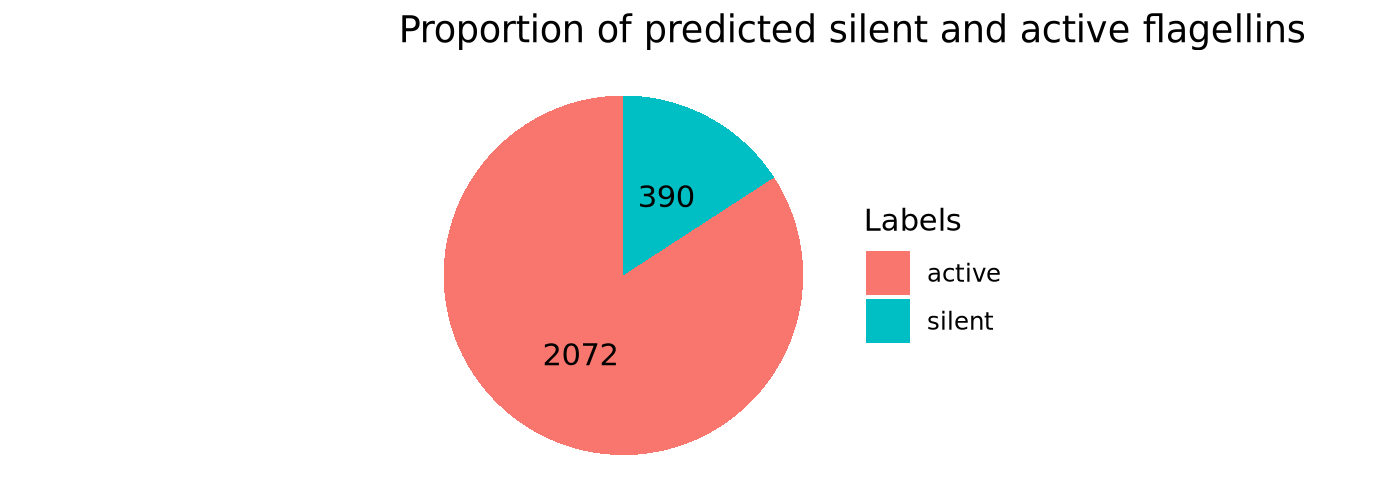

In [38]:
p.dims(7, 2.5)
plot_prediction_distribution_pie(df_full, "pred_s1")

### SFigure 4a: Binding vs Activity with Prediction Confidence

In [39]:
# data for binding/activity plot
df_ba_plot <- df_full %>%
    filter(!is.na(Exp.phenotype)) %>%
    mutate(Status = if_else(pred_s1 == Exp.phenotype, 'match', 'mismatch'))

# Define experimental reference regions from (Clasen, 2023)
df_base = data.frame(
    xmin = c(-2.066, -6, -6),
    xmax = c(0.220993633, -2.066, -2.066),
    ymin = c(0, 0, 0.1144),
    ymax = c(3.75, 0.1144, 3.75),
    status = c('Active', 'Evader', 'Silent')
)

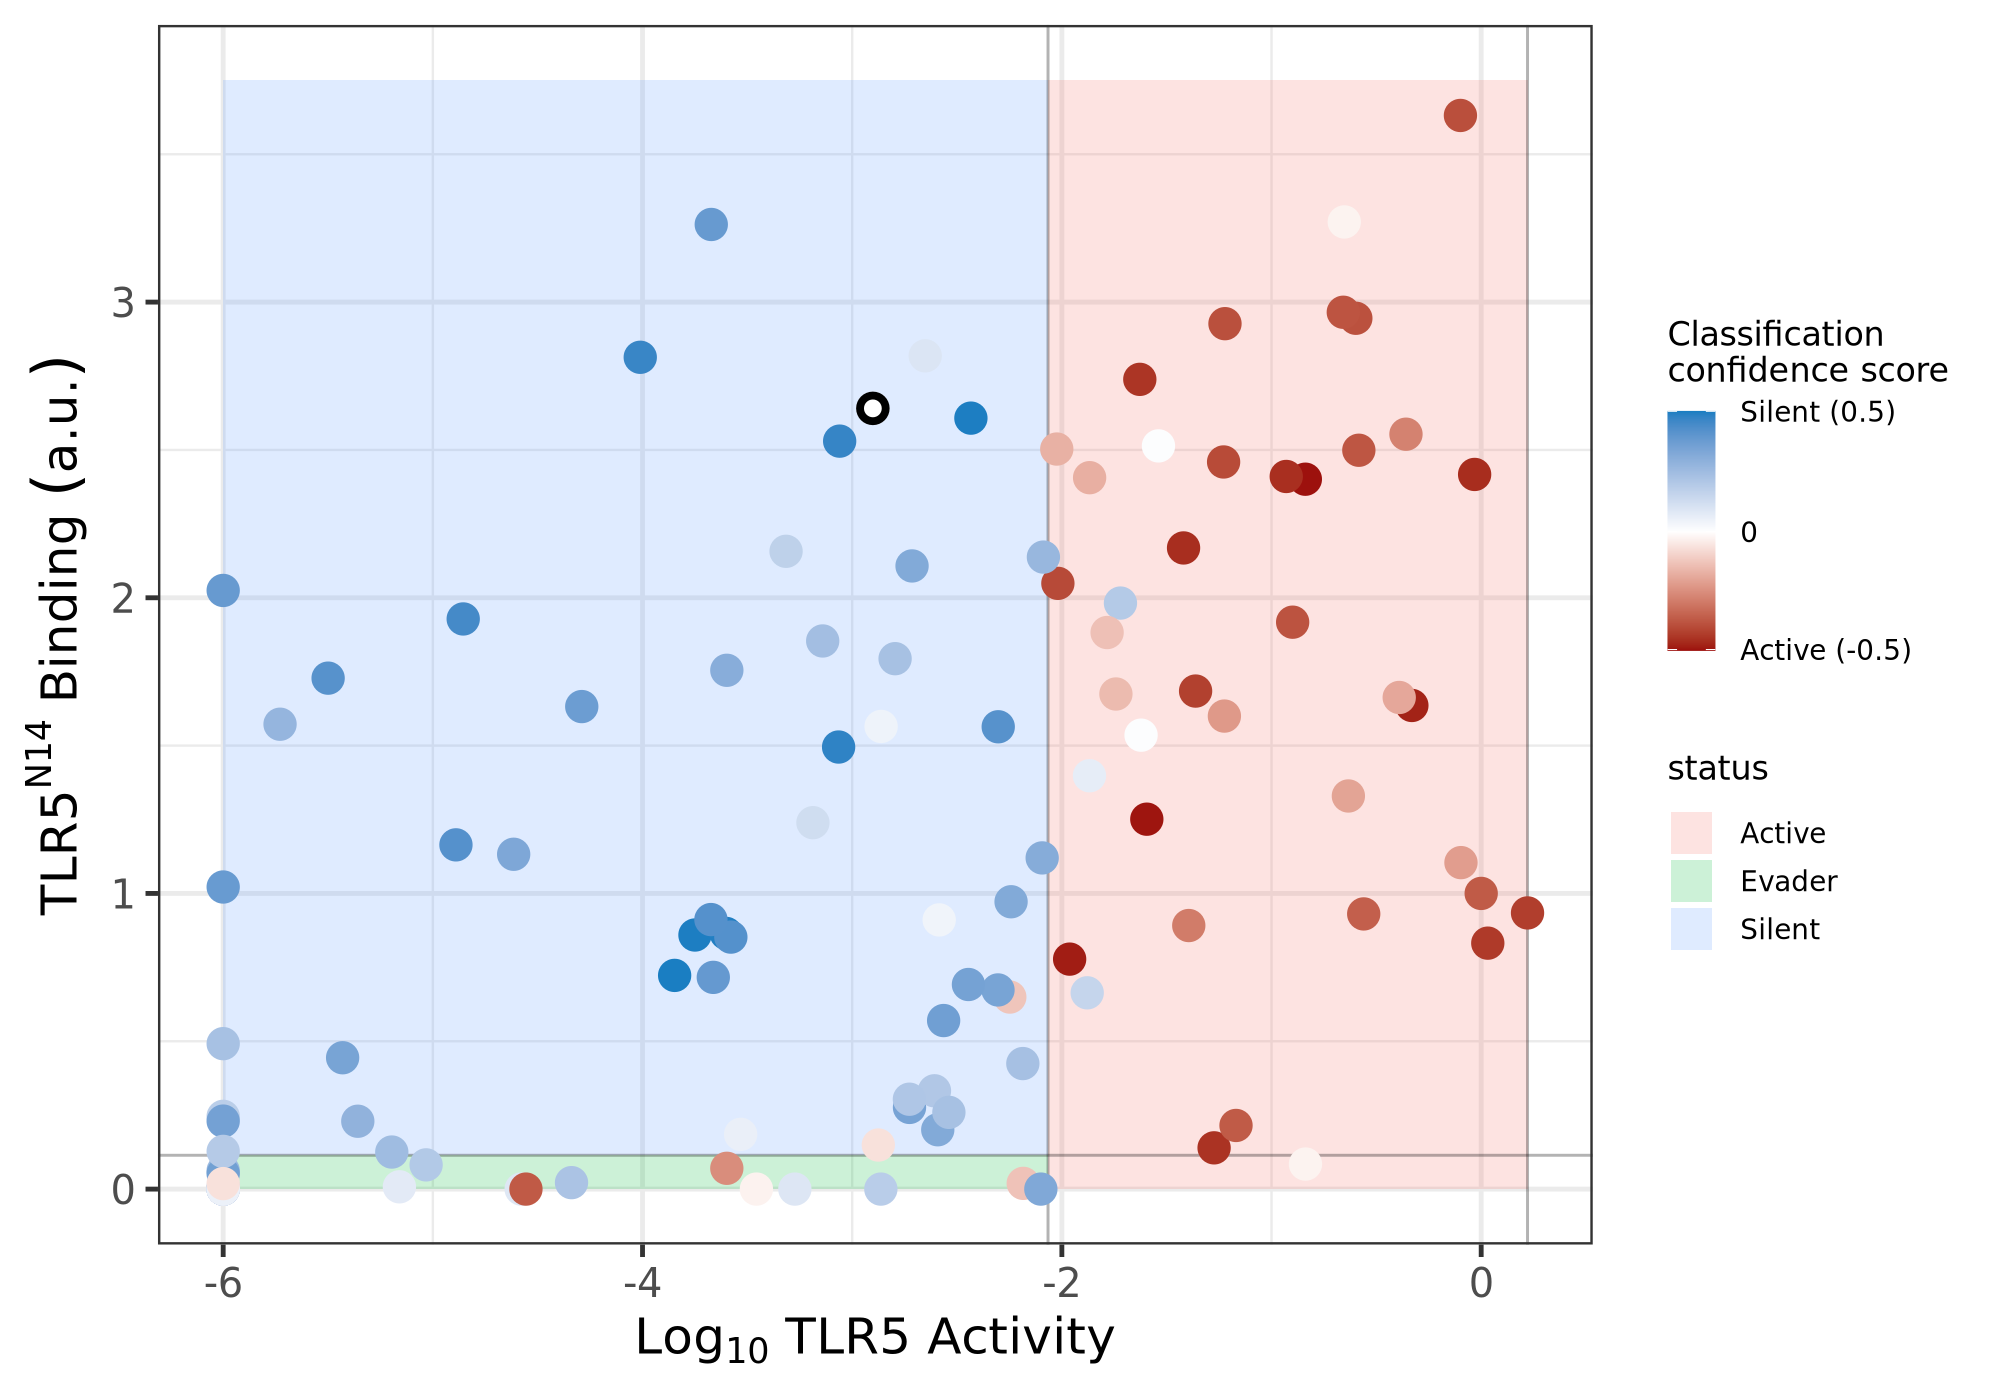

In [40]:
p.dims(10, 7)
plot_binding_activity_scatter(df_ba_plot, df_base)

### SFigure 4c: Mixed Homology Clusters

In [41]:
# Identify mixed clusters (clusters with both active and silent predictions)
mixed_clusters <- df_full %>%
    rownames_to_column(var = 'Flagellin_ID') %>%
    group_by(Cluster_CDHit) %>%
    mutate(n_fla_in_cluster = n()) %>%
    filter(n_fla_in_cluster > 1) %>%
    count(pred_s1) %>%
    mutate(Cluster_CDHit = as.factor(Cluster_CDHit)) %>%
    filter(all(c("active", "silent") %in% pred_s1))

cat("Mixed clusters identified:", length(unique(mixed_clusters$Cluster_CDHit)), "\n")

Mixed clusters identified: 13 


Warning message in geom_bar(stat = "identity", position = "stack", aes(color = pred_s1), :
“Ignoring unknown parameters: `size`”


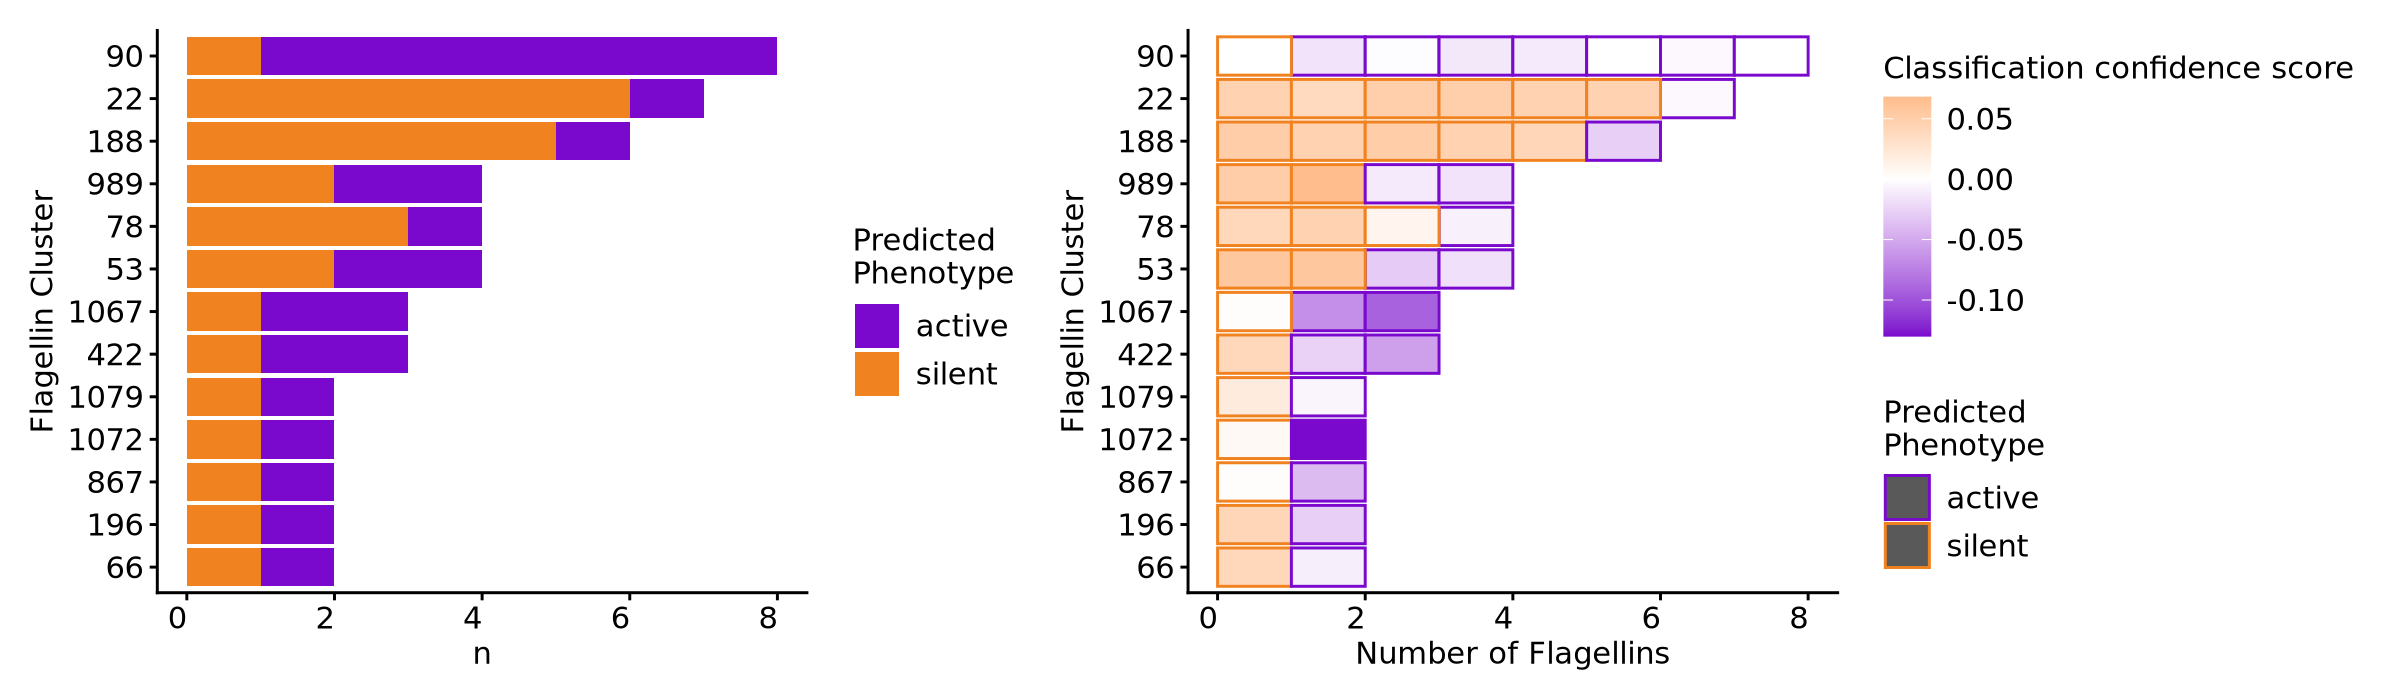

In [42]:
p.dims(12, 3.5)
plot_mixed_clusters_barplot(mixed_clusters) | plot_cluster_confidence_stacked(df_full, mixed_clusters)

## 3.6 Session Information

In [43]:
cat("\n=== REPRODUCIBILITY INFORMATION ===\n")
cat("Date:", format(Sys.time(), "%Y-%m-%d %H:%M:%S"), "\n")
cat("\nConfiguration:\n")
cat("  Data file:", params_file, "\n")
cat("  Split seed:", split_seed, "\n")
cat("  Train ratio:", train_ratio, "\n")
cat("  Include evaders:", include_evaders, "\n")
cat("  Variance threshold:", variance_threshold, "\n")
cat("\nModel parameters:\n")
cat("  Outer folds:", outer_folds, "\n")
cat("  Inner folds:", inner_folds, "\n")

cat("\nR version and packages:\n")
sessionInfo()


=== REPRODUCIBILITY INFORMATION ===
Date: 2026-03-30 16:42:58 

Configuration:
  Data file: ../../data/model_in/parameters_for_model_curated_2569_no_na_31-01-25.tsv 
  Split seed: 4321 
  Train ratio: 0.7 
  Include evaders: FALSE 
  Variance threshold: 0 



Model parameters:
  Outer folds: 10 
  Inner folds: 10 

R version and packages:


R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Debian GNU/Linux 13 (trixie)

Matrix products: default
BLAS/LAPACK: /tmp/global2/abogdanova/envs/R/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: MET
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] LeyLabRMisc_0.2.1    patchwork_1.3.2      pROC_1.19.0.1       
 [4] ggpubr_0.6.2         gridExtra_2.3        pwalign_1.2.0       
 [7] Biostrings_2.74.0    GenomeInfoDb_1.42.0  XVector_0.46.0      
[10] IRanges_2.40.0 